# Projet SVM Arthur & Thomas

## Objectif:
### Prédire si une personne se verra accorder son crédit ou non

Lien de la base de données : https://www.kaggle.com/datasets/algozee/credit-risk-and-loan-default-analysis-dataset/data

## Importation des bibliothèques

In [168]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## Importation des données et Nettoyage

In [169]:
df = pd.read_csv("data.csv")

df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [170]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   str    
 6   Education        4802 non-null   str    
 7   City             5000 non-null   str    
 8   EmploymentType   5000 non-null   str    
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 390.8 KB


In [171]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [172]:
df[df["Income"] < 0]

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
2939,65,-3731.0,10651.0,729.0,22,Male,Masters,San Francisco,Salaried,0
3263,23,-3083.0,16964.0,331.0,12,Male,PhD,New York,Salaried,0
4523,35,-213.0,14048.0,582.0,30,Female,Bachelors,Chicago,Self-Employed,0


Ces 3 observations ne sont pas forcément des fautes de frappes, il est possible qu'une personne, annuellement ne soit pas en positif.

Cependant nous remarquons une erreur entre l'age et le nombre d'année d'expérience, car comment une personne de 35 ans (ou 23ans) peut-elle avoir 30 années (ou 12 années )d'expérience ?

In [173]:
df["Age_minus_Experience"] = df["Age"] - df["YearsExperience"]

# On part du principe que les personnes qui ont une différence entre l'âge et l'expérience de travail de moins de 16 ans sont des cas suspects
result = df[df["Age_minus_Experience"] < 16]

print(len(result))

1690


Les données ne proviennent pas de clients réels, mais ont été générées artificiellement et on voit déjà une limite.
Nous allons supprimer ces données pour voir du réalisme.

In [174]:
df_clean = df.copy()
df_clean.drop(result.index, inplace=True)
result_df_clean = df_clean[df_clean["Age_minus_Experience"] < 16]
df_clean.drop("Age_minus_Experience",axis=1, inplace=True)
print(len(result_df_clean))

0


In [175]:
df_clean.isnull().sum()

Age                  0
Income             133
LoanAmount           0
CreditScore        122
YearsExperience      0
Gender               0
Education          142
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [176]:
NA_2lignes = df_clean[df_clean.isna().sum(axis=1) > 1]
print(f"{NA_2lignes}, le nombre de ligne avec 2 NA : {len(NA_2lignes)}")

      Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
13     53  48699.0     20554.0          NaN               22  Female   
442    45      NaN     14507.0          NaN               11  Female   
815    39      NaN     19507.0          NaN               20    Male   
953    63      NaN     24470.0        312.0                9    Male   
1232   64      NaN     34720.0          NaN               20    Male   
1418   49      NaN     27752.0          NaN               12  Female   
1595   27  39887.0     27750.0          NaN               11    Male   
1770   41      NaN     24299.0          NaN               13  Female   
1815   30      NaN     18666.0          NaN               11  Female   
2484   56      NaN     13932.0          NaN               25  Female   
2792   63      NaN     16632.0          NaN               36    Male   
4463   63      NaN      4596.0        827.0               15    Male   

        Education           City EmploymentType  LoanApproved  

Avoir au moins 2 valeurs manquantes représente ici  +20% des données d'une observation, pour éviter de rajouter du bruit nous allons les supprimer. De plus, supprimer uniquement 12 observation représente moins d'1% de l'échantillon.

In [177]:
df_clean=df_clean.drop(NA_2lignes.index)

In [178]:
df_clean[df_clean.isna().sum(axis=1) > 1]

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved


Pour les lignes avec uniquement 1 NA, on va remplacer les valeurs

In [179]:
df_clean["Income"] = df_clean["Income"].fillna(df_clean["Income"].mean())
df_clean["CreditScore"] = df_clean["CreditScore"].fillna(df_clean["CreditScore"].mean())
df_clean["Education"] = df_clean["Education"].fillna(df_clean["Education"].mode()[0])

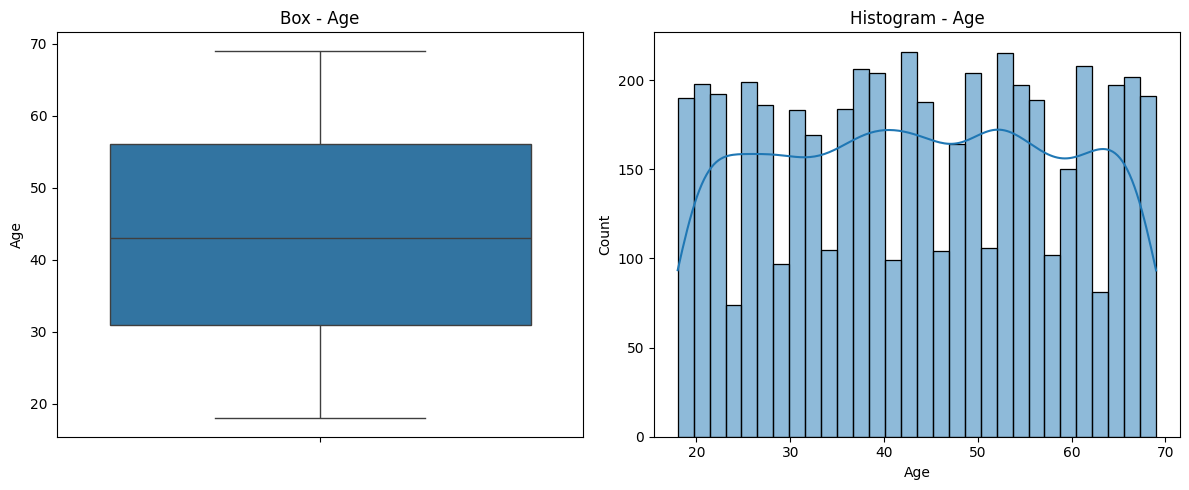

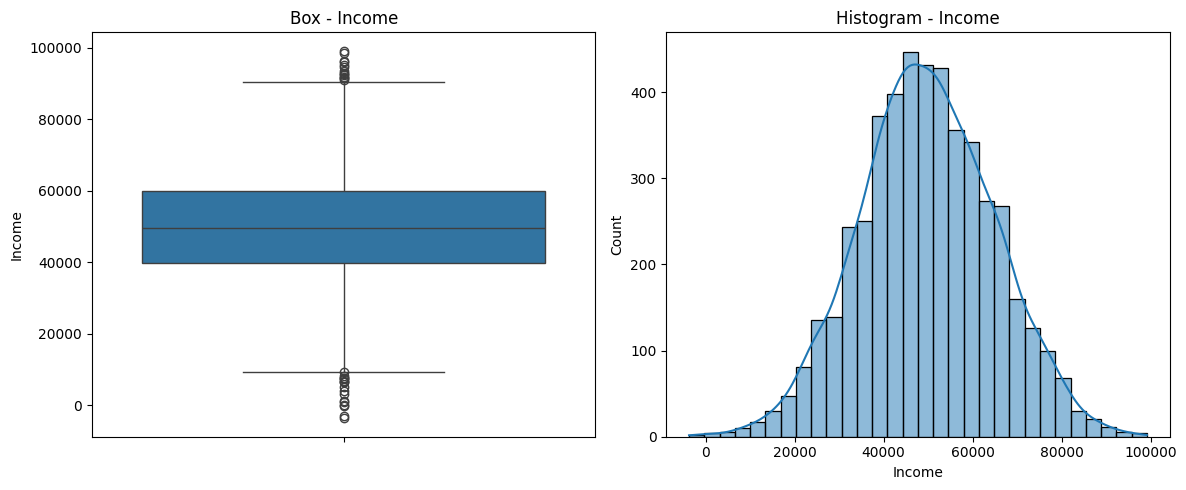

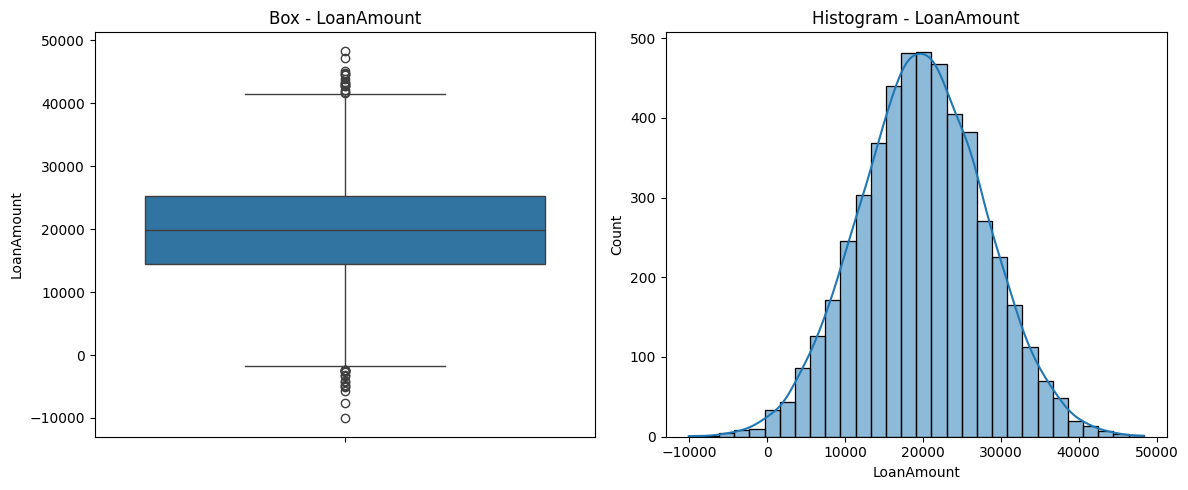

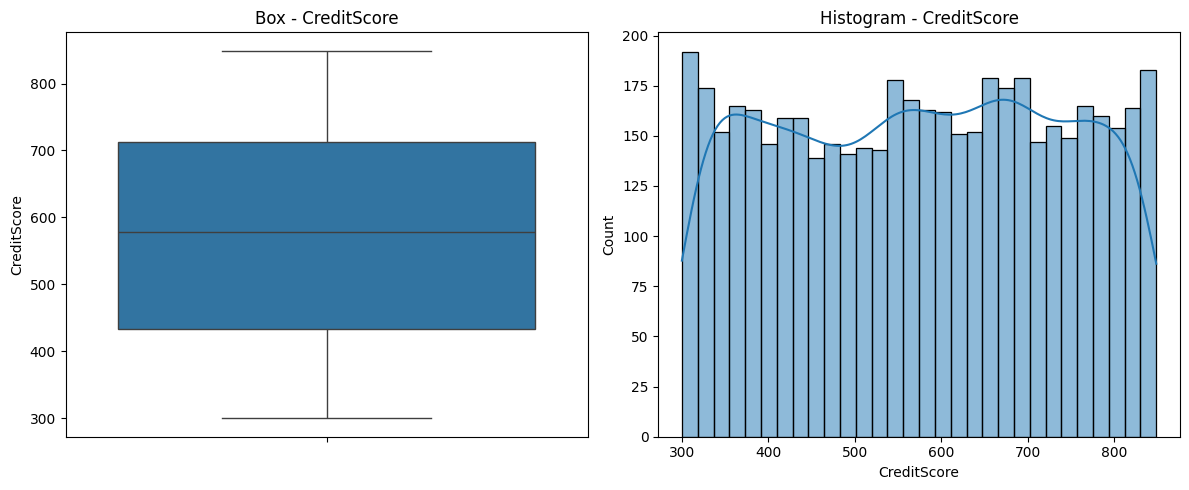

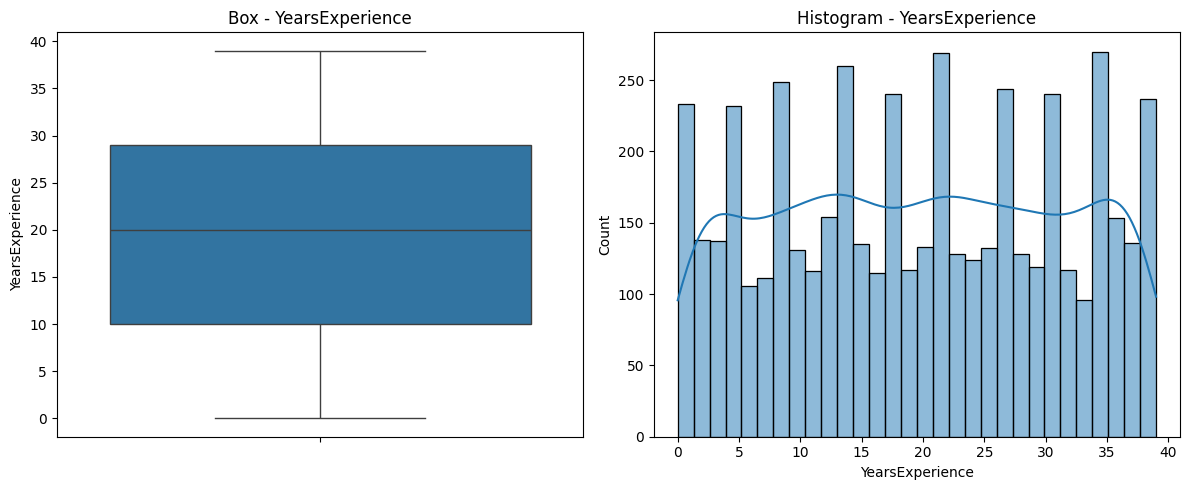

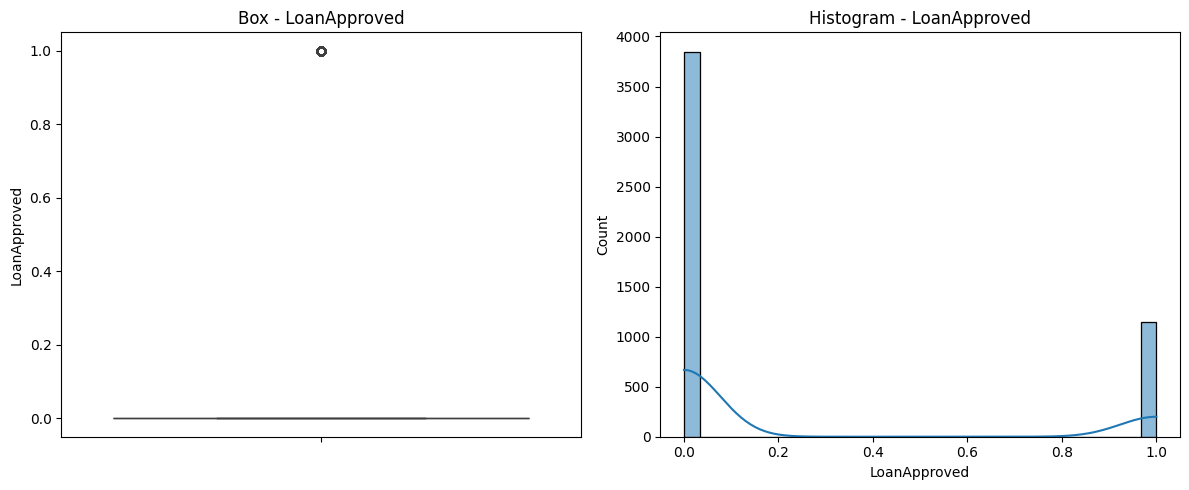

In [180]:
for col in df_clean.columns:
    if col not in ["Education", "Gender", "City", "EmploymentType"]:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Box plot
        sns.boxplot(y=df[col], ax=axes[0])
        axes[0].set_title(f"Box - {col}")

        # Histogramme
        sns.histplot(df[col], bins=30, kde=True, ax=axes[1])
        axes[1].set_title(f"Histogram - {col}")
    
        plt.tight_layout()


### Encodage des variables

In [181]:
for quali in ["Education", "Gender", "City", "EmploymentType"]:
    print(df_clean[quali].value_counts())

Education
PhD            945
Bachelors      797
High School    796
Masters        760
Name: count, dtype: int64
Gender
Male      1666
Female    1632
Name: count, dtype: int64
City
Chicago          870
San Francisco    831
New York         806
Houston          791
Name: count, dtype: int64
EmploymentType
Self-Employed    1145
Unemployed       1087
Salaried         1066
Name: count, dtype: int64


Le nombre d'occurence pour chacune des modalités est proche, de plus il y a peu de modalités, donc nous utiliserons la fonction get_dummies de pandas

In [182]:
# Chaque modalité va avoir une colonne binaire
for quali in ["Education", "Gender", "City", "EmploymentType"]:
    dummies = pd.get_dummies(df_clean[quali], drop_first=True)
    df_clean = pd.concat([df_clean, dummies], axis=1)
    df_clean.drop(columns=quali, inplace=True)

# remplace True par 1 et False 0    
bool_cols = df_clean.select_dtypes(include="bool").columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [183]:
print(df_clean.head())
print(df_clean.columns)

   Age   Income  LoanAmount  CreditScore  YearsExperience  LoanApproved  \
0   56  48353.0     31258.0        675.0               20             0   
1   69  57462.0     23262.0        586.0                6             0   
2   46  44219.0     26530.0        781.0               26             1   
3   32  56307.0     11531.0        549.0               11             0   
4   60  37034.0     27871.0        500.0               19             0   

   High School  Masters  PhD  Male  Houston  New York  San Francisco  \
0            1        0    0     0        1         0              0   
1            1        0    0     1        0         0              1   
2            0        0    1     1        1         0              0   
3            0        0    1     1        0         1              0   
4            1        0    0     0        0         0              0   

   Self-Employed  Unemployed  
0              0           1  
1              1           0  
2              1       

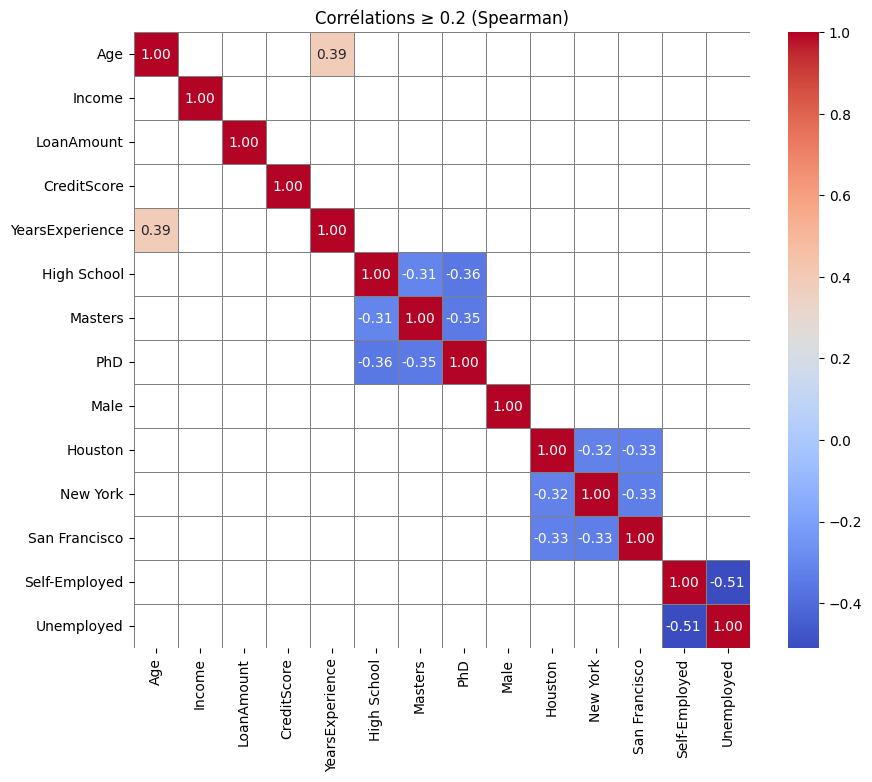

In [184]:
df_Loan = df_clean.drop(columns=["LoanApproved"]) # la variable binaire

# Sélectionner uniquement les colonnes numériques
df_numeric = df_Loan.select_dtypes(include=[np.number])

# Calculer la corrélation Spearman
corr = df_numeric.corr(method='spearman')

# Masquer les valeurs < 0.2
corr_high = corr.mask(abs(corr) < 0.2)

# Créer une figure
plt.figure(figsize=(10, 8))

# Afficher la heatmap
sns.heatmap(corr_high, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True,
            linewidths=0.5, linecolor="gray", mask=corr_high.isna())

plt.title("Corrélations ≥ 0.2 (Spearman)")
plt.show()



Les variables ne sont pas du tout corrélées entre elles.

## Visualisation des données